<h1 style="text-align: center;">Machine Learning Fundamentals</h1>

This practical assesses dataset exploration and visualization, and demonstrates how a machine learning model can be trained and
evaluated

In [29]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Data loading and exploration

### Q1: Load the Iris dataset using sklearn.datasets.load_iris() and print feature_names , target_names , and the shape of data .

In [5]:
#  Load the Iris dataset
iris = load_iris()

In [6]:
# Printing
print(iris.feature_names)
print(iris.target_names)
print(iris.data.shape)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
(150, 4)


## Q2: Provide a short written answer: What type of problem is this (classification/regression)? Why? Write your answer in a Markdown cell below.

**Answer (Q2):**

This problem is actually classification because we need to select between distinct categories(in our case iris flower types) and not some continious numeric values

<h2 style="color: red;">Q3: Show the first five rows of the data as a pandas DataFrame with column names from feature_names .</h2>

In [9]:
# Show first 5 rows as DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<h2 style="color: red;">Q4: Report class distribution (counts for each species)</h2>

**Hint** : you can use a pandas Series.

In [12]:
target_series = pd.Series(iris.target)

class_counts  = target_series.value_counts()

print(class_counts)

0    50
1    50
2    50
Name: count, dtype: int64


## Visualization

### Q5: Create a pair plot (scatter plot matrix) for the four features using matplotlib. Color points by species.

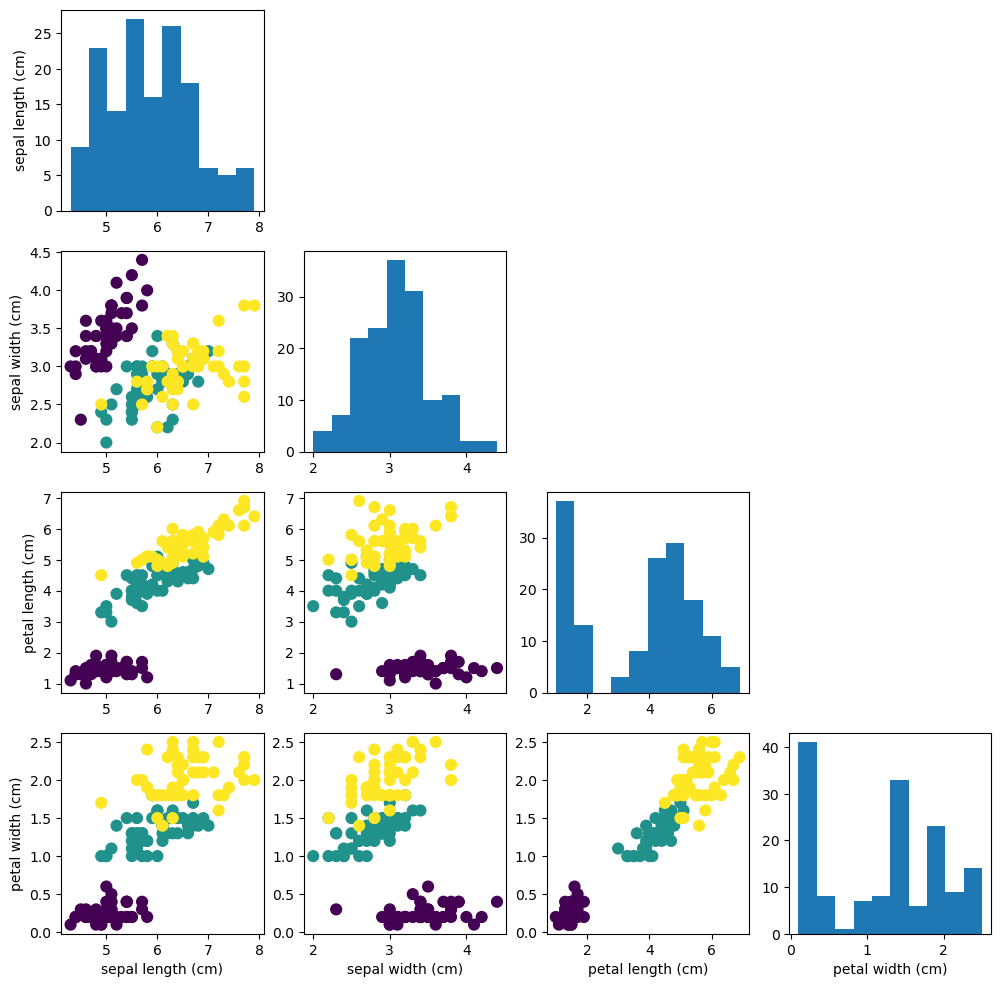

In [52]:
import matplotlib.pyplot as plt

features = iris.data
targets = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4): # Y
    for j in range(4): # X
        ax = axes[i, j]

        if i == j:
            ax.hist(features[:, i], bins=10)
        else:
            ax.scatter(features[:, j], features[:, i], c=targets, s=60)

        if i == 3:
            ax.set_xlabel(feature_names[j])
        if j == 0:
            ax.set_ylabel(feature_names[i])
        if j > i:
            ax.set_visible(False)

plt.show()


## Q6: Based on your plot, which two features appear most useful to separate the classes? Explain in one short sentence.

**Answer (Q6):**

As we see it's more easier to see which specie it is by looking at the petal length and petal width. Also their distibution is more uniqie i think


## Train - Test - split and KNN modeling

## Q7: Split the data into train/test sets (75% train, 25% test). Use stratify=target and random_state=42 . Print shapes.

In [26]:
X = iris.data
y = iris.target

X_train,  X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.25,
    stratify=y,
    random_state=42
)

In [28]:
# Print shapes.
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (37, 4)
X_test (113, 4)
y_train (37,)
y_test (113,)


### Q8: Train a KNeighborsClassifier with n_neighbors=3 . Fit on training data and report test accuracy.


In [35]:
# Train KNN 
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9734513274336283


## Q9: Compare accuracy for n_neighbors = 1, 3, 5. Report which k gives best accuracy and why (short sentence)

In [36]:
# Compare k values
k_values = [1, 3, 5]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"k={k}, Accuracy={acc}")


k=1, Accuracy=0.9557522123893806
k=3, Accuracy=0.9734513274336283
k=5, Accuracy=0.9646017699115044


**Which k is best and why?**

Write your short explanation

k = 3 gives the best accuracy because it provides a good balance between overfitting k=1 and smoothing of class boundaries which we have with too big k=5.

### Prediction

### Q10: Use your trained KNeighborsClassifier (use k=3) to predict the class of a new sample with features: [5.0, 2.9, 1.0, 0.2] . Show predicted class name.

In [49]:
sample = [[5.0, 2.9, 1.0, 0.2]]

prediction = knn.predict(sample)
print("Predicted class:", iris.target_names[prediction[0]]) # [0] because prediction returns array

Predicted class: setosa 0
